In [9]:



# You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, 
# but the internal mechanics are unknown. 

# Your objective is to find the parameter combination that maximises the function’s output, 
# such as performance, efficiency or validation accuracy. Because the function is high-dimensional 
# and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

# For example, imagine you’re tuning an ML model with eight hyperparameters: 
# learning rate, batch size, number of layers, dropout rate, regularisation strength, 
# activation function (numerically encoded), optimiser type (encoded) and initial weight range. 
# Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)

# Set random seed for reproducibility
np.random.seed(42)

-- inputs X ---
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.226981

In [11]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4","x5","x6","x7","x8"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,y
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274
39,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
22,0.145120,0.119328,0.420888,0.387609,0.155423,0.875172,0.510560,0.728611,9.141639
19,0.044329,0.013581,0.258198,0.577644,0.051280,0.158563,0.591030,0.077953,9.013075


In [12]:
df.tail()

,x1,x2,x3,x4,x5,x6,x7,x8,y
17,0.735904,0.034612,0.728030,0.147427,0.295743,0.445117,0.975180,0.374340,6.767963
24,0.176150,0.293961,0.975680,0.793936,0.923401,0.030842,0.803255,0.595898,6.451943
34,0.964573,0.973980,0.663753,0.662216,0.673122,0.905238,0.458875,0.560918,6.402588
21,0.898887,0.523642,0.876783,0.218696,0.900261,0.282766,0.911078,0.472398,5.841067
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [38]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Put this at the very top of your script
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Simplify to just Matern
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*8, 
                                      length_scale_bounds=(1e-3, 1e5), 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.2, normalize_y=True, n_restarts_optimizer=10)

gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# Optimized Kernel: 3.32**2 * Matern(length_scale=[2.63, 7.59, 1.88, 14, 2.58e+04, 1e+05, 3.72, 1e+05], nu=2.5)
# Training R^2 Score: 0.9508966963836125
# Total variance accounted for as noise: 0.2

# 5,6,8 have large scale and it is not briging any value change

Optimized Kernel: 3.32**2 * Matern(length_scale=[2.63, 7.59, 1.88, 14, 2.58e+04, 1e+05, 3.72, 1e+05], nu=2.5)
Training R^2 Score: 0.9508966963836125
Total variance accounted for as noise: 0.2


In [46]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Predict
#  increase sample to 100,000
X_grid = np.random.uniform(0, 1, size=(100000, 8)) 
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)
y_best = y.max()


In [52]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ei_next_query}")
print(f"Sigma: {sigma[ei_next_idx]}")

# best combination so far 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	     y
# 0.056447	0.065956	0.022929	0.038786	0.403935	0.801055	0.488307	0.893085	9.598482
# Suggested next: 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	                  y
# [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896 0.00987856 0.90123825]

expected_improvement with xi: 0.01
Current Best y: 9.598482002566342
Suggested next: [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896
 0.00987856 0.90123825]
Sigma: [0.42328768]


In [53]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)


ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y.max()}")
print(f"Suggested next: {ucb_next_query}")
print(f"Sigma: {sigma[ucb_next_idx]}")

# best combination so far 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	     y
# 0.056447	0.065956	0.022929	0.038786	0.403935	0.801055	0.488307	0.893085	9.598482
# Suggested next: 
#     x1	  x2	     x3	          x4	      x5	      x6	     x7	          x8	                  y
# [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896 0.00987856 0.90123825]

UCB Score with kappa: 2.0
Current Best y: 9.598482002566342
Suggested next: [0.03789746 0.01793121 0.03503221 0.22538739 0.02255555 0.62434896
 0.00987856 0.90123825]
Sigma: [0.42328768]


In [60]:
# Indices of inactive dimensions (0-indexed)
inactive_dims = [4, 5, 7]  # These are Dims 5, 6, and 8

# Clean the suggestion
ei_next_query_cleaned = ei_next_query.copy()
ei_next_query_cleaned[inactive_dims] = 0.5

ucb_next_query_cleaned = ucb_next_query.copy()
ucb_next_query_cleaned[inactive_dims] = 0.5

print(f"Cleaned Suggested next:")
print(ei_next_query_cleaned)
print(f"Cleaned Suggested next:")
print(ucb_next_query_cleaned)

# Cleaned Suggested next:
# [0.03789746 0.01793121 0.03503221 0.22538739 0.5        0.5 0.00987856 0.5       ]
# Cleaned Suggested next:
# [0.03789746 0.01793121 0.03503221 0.22538739 0.5        0.5 0.00987856 0.5       ]

# Your Next Step:Run the query using the cleaned coordinates: [0.038, 0.018, 0.035, 0.225, 0.5, 0.5, 0.010, 0.5].
# Observe the result ($y$):If $y > 9.0$: You’ve found a massive new area of high performance.If $y < 5.0$: 
# This is also a "win"—you’ve just taught the model that this corner is actually a "cliff," 
# and it will never suggest points here again.Refit: Add this $(X, y)$ pair to your training data and re-run the gp.fit().

Cleaned Suggested next:
[0.03789746 0.01793121 0.03503221 0.22538739 0.5        0.5
 0.00987856 0.5       ]
Cleaned Suggested next:
[0.03789746 0.01793121 0.03503221 0.22538739 0.5        0.5
 0.00987856 0.5       ]


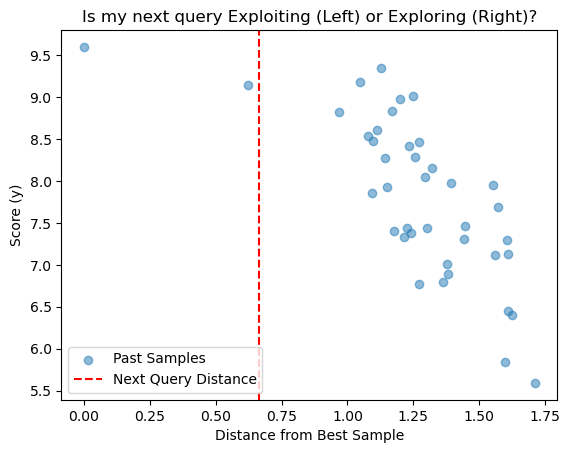

In [65]:
# Distance-to-Best Scatter (The "Where" Plot)

from scipy.spatial.distance import euclidean

# Calculate distance from current best (X[best_idx]) to all points
best_idx = np.argmax(y)
distances = [euclidean(X[best_idx], x_i) for x_i in X]

# Distance for your NEW suggested point
next_dist = euclidean(X[best_idx], ei_next_query)

plt.scatter(distances, y, alpha=0.5, label="Past Samples")
plt.axvline(next_dist, color='r', linestyle='--', label="Next Query Distance")
plt.xlabel("Distance from Best Sample")
plt.ylabel("Score (y)")
plt.legend()
plt.title("Is my next query Exploiting (Left) or Exploring (Right)?")
plt.show()

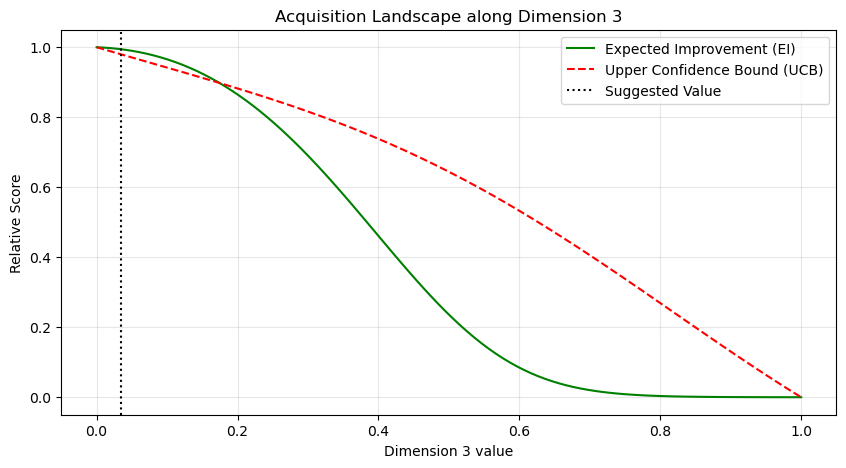

In [73]:
# Acquistion plot
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_acquisition_slice(gp, X, y, dim_idx, next_query, xi=0.01, kappa=2.0):
    # 1. Create a 1D grid for the x-axis
    x_range = np.linspace(0, 1, 100)
    
    # 2. Prepare the input: copy the 'suggested' point and vary only ONE dimension
    X_plot = np.tile(next_query, (100, 1))
    X_plot[:, dim_idx] = x_range
    
    # 3. Get predictions
    mu, sigma = gp.predict(X_plot, return_std=True)
    y_max = y.max()
    
    # 4. Calculate EI
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0] = 0.0
        
    # 5. Calculate UCB
    ucb = mu + kappa * sigma

    # 6. Plotting
    plt.figure(figsize=(10, 5))
    
    # Normalize EI and UCB to 0-1 scale so they can be compared visually
    ei_norm = (ei - ei.min()) / (ei.max() - ei.min() + 1e-9)
    ucb_norm = (ucb - ucb.min()) / (ucb.max() - ucb.min() + 1e-9)
    
    plt.plot(x_range, ei_norm, 'g-', label='Expected Improvement (EI)')
    plt.plot(x_range, ucb_norm, 'r--', label='Upper Confidence Bound (UCB)')
    
    # Mark where your suggested point is
    plt.axvline(next_query[dim_idx], color='black', linestyle=':', label='Suggested Value')
    
    plt.title(f'Acquisition Landscape along Dimension {dim_idx + 1}')
    plt.xlabel(f'Dimension {dim_idx + 1} value')
    plt.ylabel('Relative Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it for Dimension 3 (index 2)
# Use your cleaned next_query from the previous step
# next_query = np.array([0.038, 0.018, 0.035, 0.225, 0.5, 0.5, 0.010, 0.5])
plot_acquisition_slice(gp, X, y, dim_idx=2, next_query=ei_next_query_cleaned)

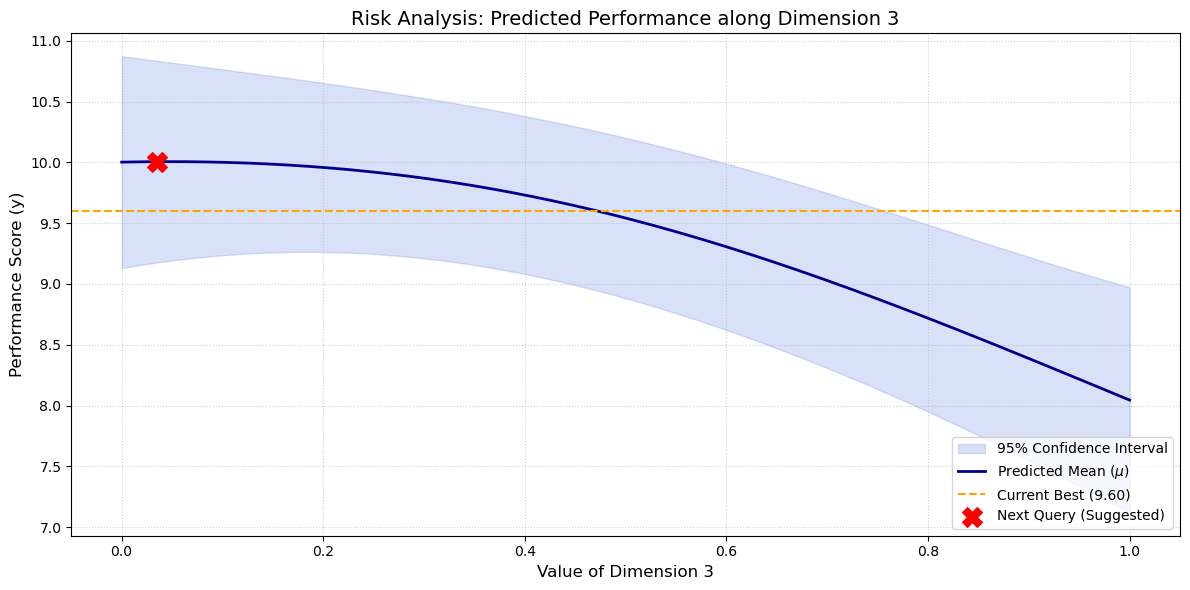

In [74]:

import numpy as np
import matplotlib.pyplot as plt

def plot_risk_dashboard(gp, X, y, next_query, dim_idx=2):
    """
    gp: Your trained GaussianProcessRegressor
    X: Your training inputs (shape: 40, 8)
    y: Your training targets (shape: 40,)
    next_query: The 8D coordinate suggested [0.038, 0.018, ...]
    dim_idx: The dimension to vary (2 for Dim 3)
    """
    # 1. Generate the slice data
    n_points = 200
    x_range = np.linspace(0, 1, n_points)
    
    # Create a grid where all dims are fixed EXCEPT the one we are plotting
    X_plot = np.tile(next_query, (n_points, 1))
    X_plot[:, dim_idx] = x_range
    
    # 2. Get GP Predictions (Mean and Standard Deviation)
    mu, sigma = gp.predict(X_plot, return_std=True)
    y_max = y.max()
    
    # 3. Predict the specific value for the 'Next Query' marker
    mu_s, sigma_s = gp.predict(next_query.reshape(1, -1), return_std=True)

    # 4. Create the Plot
    plt.figure(figsize=(12, 6))
    
    # Plot the 95% Confidence Interval (The "Risk" area)
    plt.fill_between(x_range, mu - 1.96*sigma, mu + 1.96*sigma, 
                     color='royalblue', alpha=0.2, label='95% Confidence Interval')
    
    # Plot the Mean Prediction
    plt.plot(x_range, mu, color='darkblue', lw=2, label='Predicted Mean ($\mu$)')
    
    # Plot the Current Best Score
    plt.axhline(y_max, color='orange', linestyle='--', lw=1.5, label=f'Current Best ({y_max:.2f})')
    
    # Plot the Suggested Next Query point
    plt.scatter([next_query[dim_idx]], [mu_s], color='red', marker='X', s=200, 
                zorder=5, label='Next Query (Suggested)')

    # Formatting
    plt.title(f'Risk Analysis: Predicted Performance along Dimension {dim_idx + 1}', fontsize=14)
    plt.xlabel(f'Value of Dimension {dim_idx + 1}', fontsize=12)
    plt.ylabel('Performance Score (y)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', frameon=True)
    
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN ---
# Replace 'gp', 'X', and 'y' with your actual variables
# next_query = np.array([0.038, 0.018, 0.035, 0.225, 0.5, 0.5, 0.010, 0.5])
plot_risk_dashboard(gp, X, y, next_query=ei_next_query_cleaned, dim_idx=2)